# Reducing Bitrate While Preserving Quality: Appear vs. Nevion for CBC/Radio-Canada

## Declare imports, load files, and define plotting functions

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np

# Define the metric order to extract
metric_keys = ['psnr_y', 'psnr_cb', 'psnr_cr', 'psnr_hvs_y', 'float_ms_ssim', 'ciede2000', 'vmaf']
n_metrics = len(metric_keys)

sequences = ['Aviron', 'Confettis', 'Hockey', 'Velos']
nevion_bitrates = [80, 100, 120]
appear_bitrates = [30, 40, 50, 60]
n_nevion_bitrates = len(nevion_bitrates)
n_appear_bitrates = len(appear_bitrates)

nevion_metrics = {}
appear_metrics = {}
nevion_array_sum = np.zeros((n_nevion_bitrates, n_metrics + 1))
appear_array_sum = np.zeros((n_appear_bitrates, n_metrics + 1))

for s in sequences:
    nevion_array = np.empty((0, n_metrics + 1))
    appear_array = np.empty((0, n_metrics + 1))
    for b in nevion_bitrates:
        with open('NEVION/%dMbps/%s.json' % (b, s), 'r') as file:
            data = json.load(file)
        # Extract the required metrics
        extracted_metrics = [data['pooled_metrics'][metric]['mean'] for metric in metric_keys]
        extracted_metrics.insert(0, b)
        nevion_array = np.append(nevion_array, [extracted_metrics], axis=0)
    nevion_metrics[s] = nevion_array
    nevion_array_sum = nevion_array_sum + nevion_array

    for b in appear_bitrates:
        with open('APPEAR/1080i5994/LowLatency/%dMbps/%s.json' % (b, s), 'r') as file:
            data = json.load(file)
        # Extract the required metrics
        extracted_metrics = [data['pooled_metrics'][metric]['harmonic_mean'] for metric in metric_keys]
        extracted_metrics.insert(0, b)
        appear_array = np.append(appear_array, [extracted_metrics], axis=0)
    appear_metrics[s] = appear_array
    appear_array_sum = appear_array_sum + appear_array
    
nevion_metrics['Average'] = nevion_array_sum / len(sequences)
appear_metrics['Average'] = appear_array_sum / len(sequences)

def std(metrics, n_metrics, n_bitrates):
    std = np.zeros((n_bitrates, n_metrics + 1))
    for b in range(0,n_bitrates):
        std_array = np.empty((0, n_metrics + 1))
        for s in sequences:
            std_array = np.append(std_array, [metrics[s][b]], axis=0)
        std[b] = np.std(std_array, axis=0)
    return std

nevion_metrics['Stdev'] = std(nevion_metrics, n_metrics, n_nevion_bitrates)
appear_metrics['Stdev'] = std(appear_metrics, n_metrics, n_appear_bitrates)

# Function to plot RD charts for different metrics
def plot_rd_curve(nevion_bitrates, appear_bitrates, nevion_values, appear_values, nevion_std, appear_std, metric_name):
    xticks = [20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130]
    
    plt.figure(figsize=(12, 6))
    
    # Plot with markers and line
    #plt.plot(nevion_bitrates, nevion_values, marker='o', markersize=8, linewidth=2, label='Nevion', color='tab:blue')
    plt.errorbar(nevion_bitrates, nevion_values, yerr=nevion_std, fmt='o-', 
                 markersize=8, linewidth=2, label="Nevion", color='tab:blue', ecolor='lightgray', capsize=2)
    plt.errorbar(appear_bitrates, appear_values, yerr=appear_std, fmt='o-',
                 markersize=8, linewidth=2, label='Appear', color='tab:red', ecolor='lightgray', capsize=2)
    plt.axhline(y=nevion_values[-1], color='gray', linestyle='--', linewidth=2, label=f'Baseline')
    
    # Customize appearance
    plt.xlabel('Bitrate (Mbps)', fontsize=12, fontweight='bold')
    plt.ylabel(metric_name, fontsize=12, fontweight='bold')
    plt.title(f'{metric_name} vs Bitrate', fontsize=14, fontweight='bold')
    plt.grid(True, linestyle=':', linewidth=1, alpha=0.6)
    
    # Improve aesthetics
    plt.xticks(xticks,fontsize=11)
    plt.yticks(fontsize=11)
    plt.legend(fontsize=12)
    plt.tight_layout()
    
    # Show the plot
    plt.savefig((f'{metric_name}_vs_bitrate.png'), dpi=300, bbox_inches='tight');
    plt.show()


## Analysis of PSNR vs Bitrate for Nevion and Appear Encoding Solutions

The following graph presents a comparison of the PSNR-Y (Peak Signal-to-Noise Ratio for the Y channel) values as a function of bitrate for two different encoding solutions: Nevion and Appear. The x-axis represents the bitrate in Mbps, while the y-axis indicates the PSNR-Y values in decibels (dB), a common measure of video quality—where higher values correspond to better visual fidelity.

PSNR provides a straightforward, objective numerical method for comparing video quality across different bitrates and encoding schemes. However, PSNR has its limitations—it does not always align with subjective human visual perception. While a higher PSNR indicates greater fidelity in terms of signal reconstruction, it does not necessarily equate to better perceived quality. This is because PSNR primarily measures pixel-wise differences and fails to account for important perceptual aspects such as spatial and temporal artifacts, including motion smoothness and structural distortions.

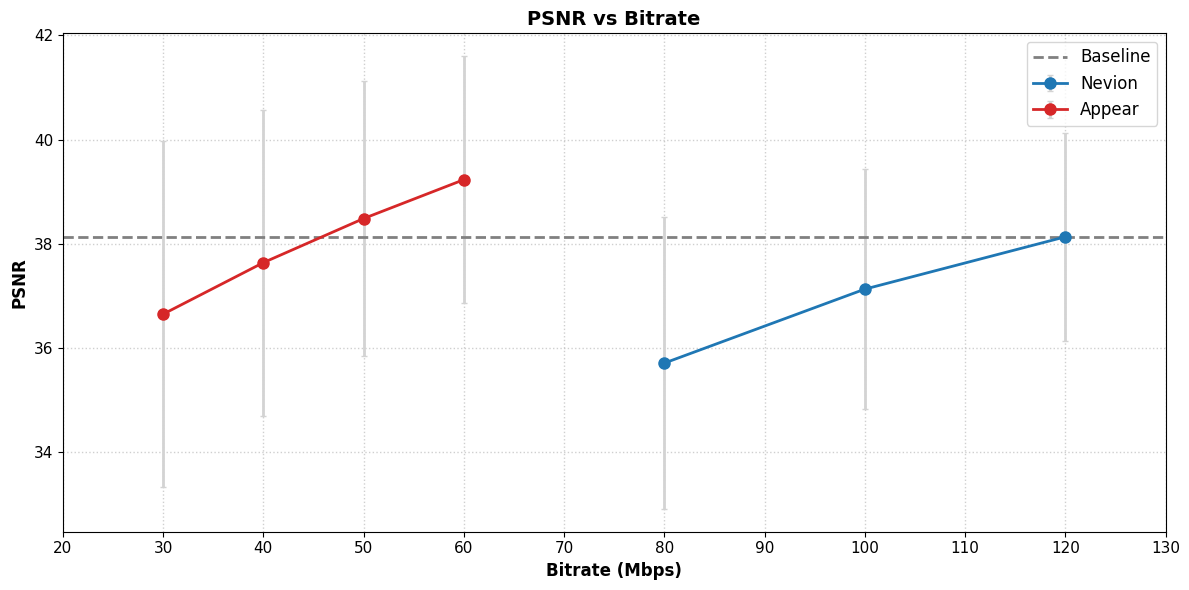

In [2]:
nevion_psnr = 14/16 * nevion_metrics['Average'][:, 1] + 1/16 * nevion_metrics['Average'][:, 2] + 1/16 * nevion_metrics['Average'][:, 3]
appear_psnr = 14/16 * appear_metrics['Average'][:, 1] + 1/16 * appear_metrics['Average'][:, 2] + 1/16 * appear_metrics['Average'][:, 3]
nevion_psnr_std = nevion_metrics['Stdev'][:, 1]
appear_psnr_std = appear_metrics['Stdev'][:, 1]
plot_rd_curve(nevion_bitrates, appear_bitrates, nevion_psnr, appear_psnr, nevion_psnr_std, appear_psnr_std, "PSNR")


## Analysis of MS-SSIM vs Bitrate for Nevion and Appear Encoding Solutions

The following graph presents a comparison of the MS-SSIM (Multi-Scale Structural Similarity Index) values as a function of bitrate for two different encoding solutions: Nevion and Appear. The x-axis represents the bitrate in Mbps, while the y-axis indicates the MS-SSIM values, which range from 0 to 1, with values closer to 1 representing better structural similarity to the original content.

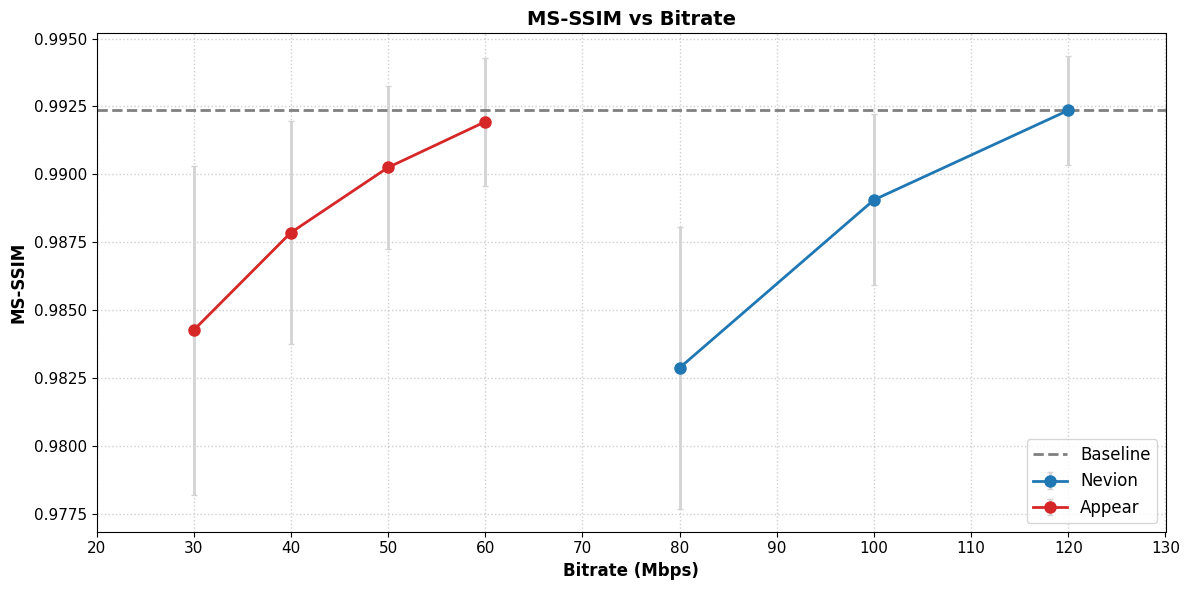

In [3]:
nevion_ms_ssim = nevion_metrics['Average'][:, 5]
appear_ms_ssim = appear_metrics['Average'][:, 5]
nevion_ms_ssim_std = nevion_metrics['Stdev'][:, 5]
appear_ms_ssim_std = appear_metrics['Stdev'][:, 5]
plot_rd_curve(nevion_bitrates, appear_bitrates, nevion_ms_ssim, appear_ms_ssim, nevion_ms_ssim_std, appear_ms_ssim_std, "MS-SSIM")

## Analysis of CIEDE2000 vs Bitrate for Nevion and Appear Encoding Solutions

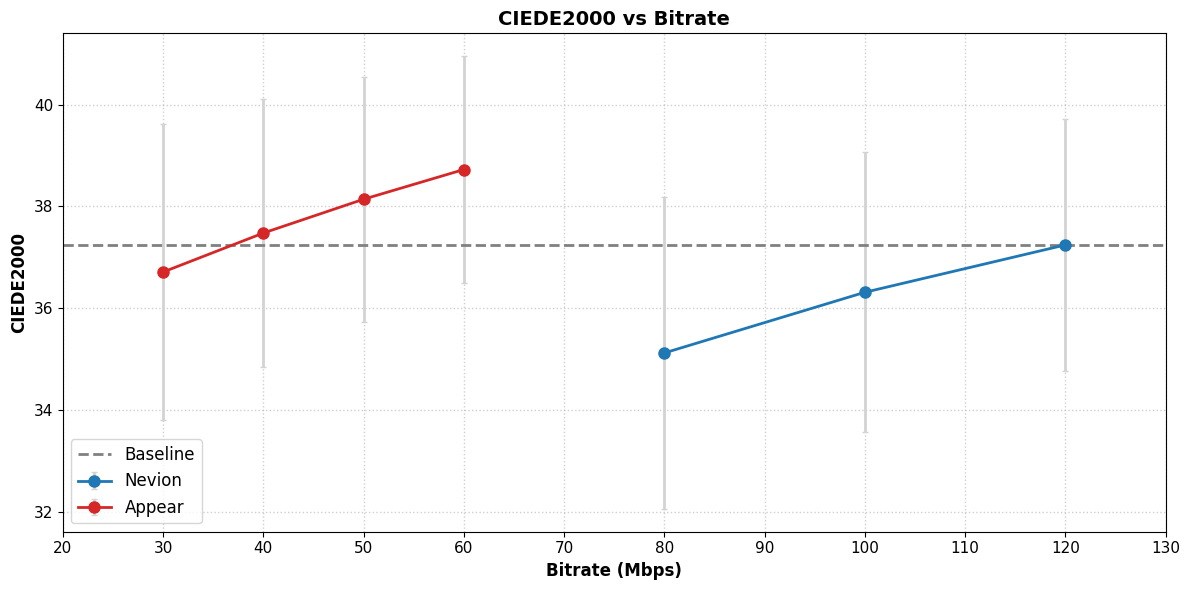

In [4]:
nevion_ciede = nevion_metrics['Average'][:, 6]
appear_ciede = appear_metrics['Average'][:, 6]
nevion_ciede_std = nevion_metrics['Stdev'][:, 6]
appear_ciede_std = appear_metrics['Stdev'][:, 6]
plot_rd_curve(nevion_bitrates, appear_bitrates, nevion_ciede, appear_ciede, nevion_ciede_std, appear_ciede_std, "CIEDE2000")

## Analysis of VMAF vs Bitrate for Nevion and Appear Encoding Solutions

The default VMAF model (model/vmaf_v0.6.1.json) is trained to predict the quality of videos displayed on a 1080p HDTV in a living-room-like environment. All the subjective data were collected in such a way that the distorted videos (with native resolutions of 1080p, 720p, 480p etc.) get rescaled to 1080 resolution and shown on the 1080p display with a viewing distance of three times the screen height (3H). Note that 3H is the critical distance for a viewer to appreciate 1080p resolution sharpness (see recommendation).


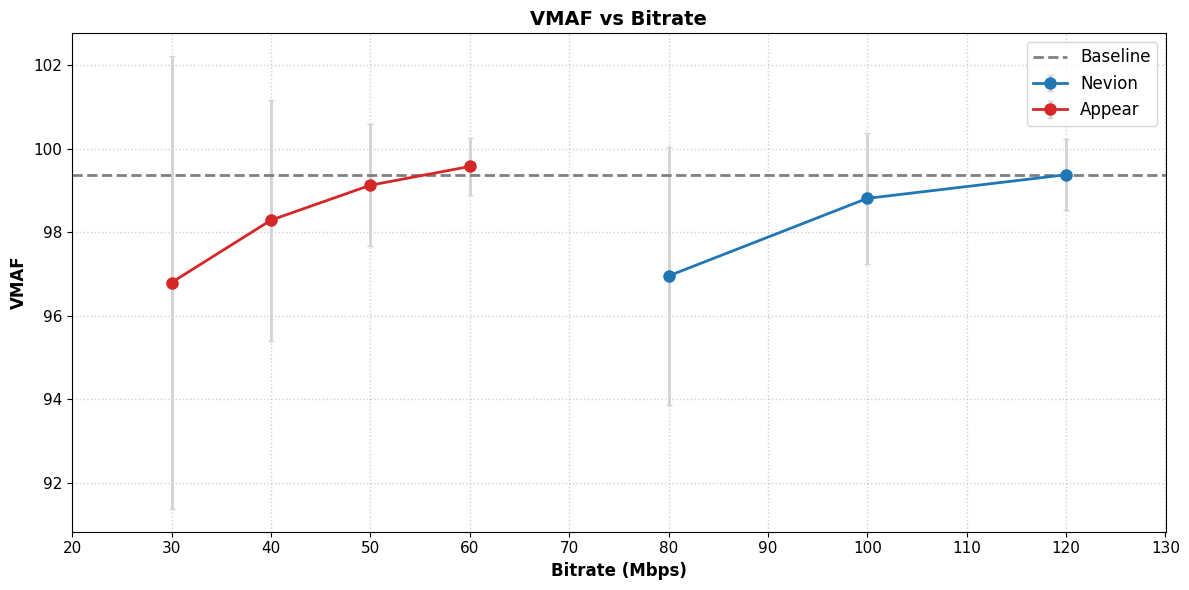

In [5]:
nevion_vmaf = nevion_metrics['Average'][:, 7]
appear_vmaf = appear_metrics['Average'][:, 7]
nevion_vmaf_std = nevion_metrics['Stdev'][:, 7]
appear_vmaf_std = appear_metrics['Stdev'][:, 7]
plot_rd_curve(nevion_bitrates, appear_bitrates, nevion_vmaf, appear_vmaf, nevion_vmaf_std, appear_vmaf_std, "VMAF")

# PSNR HVS

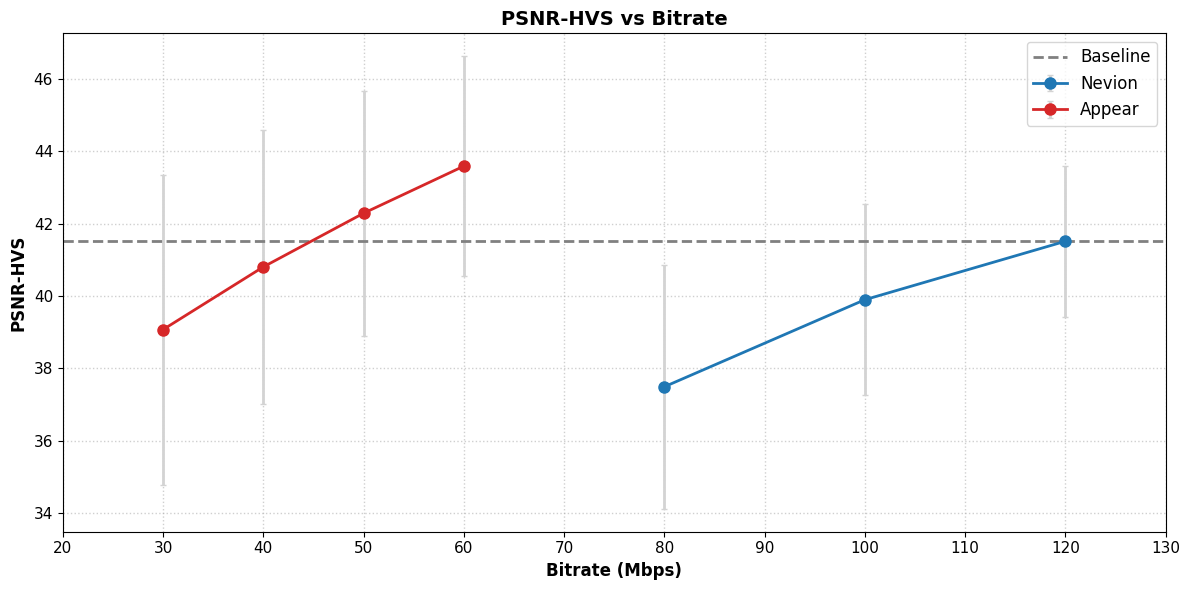

In [6]:
nevion_psnrhvs = nevion_metrics['Average'][:, 4]
appear_psnrhvs = appear_metrics['Average'][:, 4]
nevion_psnrhvs_std = nevion_metrics['Stdev'][:, 4]
appear_psnrhvs_std = appear_metrics['Stdev'][:, 4]
plot_rd_curve(nevion_bitrates, appear_bitrates, nevion_psnrhvs, appear_psnrhvs, nevion_psnrhvs_std, appear_psnrhvs_std, "PSNR-HVS")